# Accelerated Douglas–Rachford Splitting
## Three Fully Nonsmooth Problems

All three problems are **APG-incompatible**: both $g_1$ and $g_2$ are nonsmooth, so there is no gradient step to take.

| # | Problem | $g_1$ | $g_2$ | Prox complexity |
|---|---------|--------|--------|-----------------|
| 1 | Basis Pursuit: $\min\|x\|_1$ s.t. $Ax=b$ | $\ell_1$ norm | Affine indicator | Soft-thresh + linear solve |
| 2 | Nuclear norm + nonnegativity: $\min\|X-M\|_*$ s.t. $X\geq 0$ | Shifted nuclear norm | Nonnegativity indicator | SVD + ReLU |
| 3 | Constrained elastic net: $\min\|x\|_1 + \frac{\mu}{2}\|x\|^2$ s.t. $Ax=b$ | Elastic net | Affine indicator | Scaled soft-thresh + linear solve |

**Algorithms compared** (all track $F(u_k)$ where $u_k = \mathrm{prox}_{\alpha g_2}(2x_k - z_k)$ is always feasible for $g_2$):

| Algorithm | Idea | Prox evals/iter |
|-----------|------|----------------|
| **DRS** | Classical fixed-point iteration | 2 |
| **ADRS** | Inertial extrapolation + residual restart | ~2 |
| **ADRS-M** | Monitor: compute both inertial & safe, pick better | 4 |
| **ADRS-M-NM** | Nonmonotone monitor: safe step only when needed | ~2 avg |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(0)
plt.rcParams.update({'font.size': 12, 'lines.linewidth': 2,
                     'axes.grid': True, 'grid.alpha': 0.3})

COLORS = {'DRS': '#1f77b4', 'ADRS': '#ff7f0e',
          'ADRS-M': '#2ca02c', 'ADRS-M-NM': '#d62728'}
STYLES = {'DRS': '-', 'ADRS': '--', 'ADRS-M': '-.', 'ADRS-M-NM': ':'}


## Algorithm implementations

The DRS operator applied to $\min g_1(x) + g_2(x)$ is:
$$x_k = \mathrm{prox}_{\alpha g_1}(z_k),\quad u_k = \mathrm{prox}_{\alpha g_2}(2x_k - z_k),\quad z_{k+1} = z_k + u_k - x_k$$

The **residual** $r_k = \|u_k - x_k\| \to 0$ at convergence and serves as the stationarity measure for the monitor/restart logic.


In [2]:
def make_algorithms(prox1, prox2, objective, ALPHA):
    """Return all four algorithms bound to a specific problem's prox operators."""

    # ------------------------------------------------------------------
    # DRS
    # ------------------------------------------------------------------
    def run_drs(z0, niters):
        z = z0.copy(); objs, resids = [], []
        for _ in range(niters):
            x = prox1(z, ALPHA)
            u = prox2(2*x - z, ALPHA)
            r = np.linalg.norm(u - x)
            z = z + u - x
            objs.append(objective(u)); resids.append(r)
        return np.array(objs), np.array(resids)

    # ------------------------------------------------------------------
    # ADRS: inertial DRS + residual restart
    # ------------------------------------------------------------------
    def run_adrs(z0, niters):
        z, z_prev = z0.copy(), z0.copy()
        t, r_prev = 1.0, np.inf
        objs, resids = [], []
        for _ in range(niters):
            t_new = (1 + np.sqrt(1 + 4*t**2)) / 2
            beta  = (t - 1) / t_new
            y     = z + beta * (z - z_prev)
            x = prox1(y, ALPHA); u = prox2(2*x - y, ALPHA)
            r = np.linalg.norm(u - x)
            if r > r_prev:                        # restart
                t_new = 1.0
                x_s = prox1(z, ALPHA); u_s = prox2(2*x_s - z, ALPHA)
                r   = np.linalg.norm(u_s - x_s)
                z_prev = z.copy(); z = z + u_s - x_s; u = u_s
            else:
                z_prev = z.copy(); z = y + u - x
            t, r_prev = t_new, r
            objs.append(objective(u)); resids.append(r)
        return np.array(objs), np.array(resids)

    # ------------------------------------------------------------------
    # ADRS-M: monitor variant — always compute both candidates
    # ------------------------------------------------------------------
    def run_adrs_m(z0, niters):
        z, z_prev = z0.copy(), z0.copy()
        t = 1.0; objs, resids = [], []; n_in = 0
        for _ in range(niters):
            t_new = (1 + np.sqrt(1 + 4*t**2)) / 2
            beta  = (t - 1) / t_new
            y     = z + beta * (z - z_prev)
            xI = prox1(y, ALPHA); uI = prox2(2*xI - y, ALPHA); rI = np.linalg.norm(uI - xI)
            xS = prox1(z, ALPHA); uS = prox2(2*xS - z, ALPHA); rS = np.linalg.norm(uS - xS)
            if rI <= rS:
                z_prev, z, u, r = z.copy(), y + uI - xI, uI, rI; n_in += 1
            else:
                z_prev, z, u, r = z.copy(), z + uS - xS, uS, rS; t_new = 1.0
            t = t_new
            objs.append(objective(u)); resids.append(r)
        print(f"  ADRS-M:    inertial {n_in}/{niters} ({100*n_in/niters:.0f}%)")
        return np.array(objs), np.array(resids)

    # ------------------------------------------------------------------
    # ADRS-M-NM: nonmonotone monitor — safe step only when needed
    # ------------------------------------------------------------------
    def run_adrs_m_nm(z0, niters):
        z, z_prev = z0.copy(), z0.copy()
        t = 1.0
        xi = prox1(z, ALPHA); ui = prox2(2*xi - z, ALPHA)
        c  = np.linalg.norm(ui - xi)          # strict monotone reference (eta=0)
        objs, resids = [], []; n_in = 0
        for _ in range(niters):
            t_new = (1 + np.sqrt(1 + 4*t**2)) / 2
            beta  = (t - 1) / t_new
            y     = z + beta * (z - z_prev)
            xI = prox1(y, ALPHA); uI = prox2(2*xI - y, ALPHA); rI = np.linalg.norm(uI - xI)
            if rI <= c:
                z_prev, z, u, r = z.copy(), y + uI - xI, uI, rI; n_in += 1
            else:
                xS = prox1(z, ALPHA); uS = prox2(2*xS - z, ALPHA)
                rS = np.linalg.norm(uS - xS)
                z_prev, z, u, r = z.copy(), z + uS - xS, uS, rS; t_new = 1.0
            c = r; t = t_new
            objs.append(objective(u)); resids.append(r)
        print(f"  ADRS-M-NM: inertial {n_in}/{niters} ({100*n_in/niters:.0f}%)")
        return np.array(objs), np.array(resids)

    return {'DRS': run_drs, 'ADRS': run_adrs,
            'ADRS-M': run_adrs_m, 'ADRS-M-NM': run_adrs_m_nm}


In [3]:
def run_and_plot(algos, z0, niters, f_star, title, fname=None):
    """Run all algorithms and produce the standard two-panel plot."""
    results = {}
    print(f"Running: {title}")
    for name, fn in algos.items():
        results[name] = fn(z0, niters)

    iters = np.arange(1, niters + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for name, (objs, resids) in results.items():
        c, ls = COLORS[name], STYLES[name]
        axes[0].semilogy(iters, objs,   color=c, linestyle=ls, label=name)
        axes[1].semilogy(iters, resids, color=c, linestyle=ls, label=name)

    axes[0].axhline(f_star, color='black', lw=1, linestyle='--',
                    label=f'$F^\\star = {f_star:.2f}$')
    axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('$F(u_k)$')
    axes[0].set_title('Objective (feasible iterate)'); axes[0].legend(fontsize=10)
    axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('$r_k = \\|u_k - x_k\\|$')
    axes[1].set_title('DRS residual'); axes[1].legend(fontsize=10)

    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()

    # Summary table
    tols = [1.0, 0.1, 0.01, 1e-3, 1e-4]
    print(f"\n{'Algorithm':<14}", end="")
    for t in tols:
        print(f"  gap<{t:.0e}", end="")
    print()
    print("-" * 65)
    for name, (objs, _) in results.items():
        gaps = objs - f_star
        print(f"{name:<14}", end="")
        for t in tols:
            h = np.where(gaps < t)[0]
            print(f"  {str(h[0]+1) if len(h) else 'N/A':>8}", end="")
        print()
    print()
    return results


---
## Problem 1: Basis Pursuit

$$\min_{x \in \mathbb{R}^n} \|x\|_1 \quad\text{s.t.}\quad Ax = b$$

**Splitting**: $g_1 = \|\cdot\|_1$, $g_2 = \iota_{\{Ax=b\}}$

- $\mathrm{prox}_{\alpha g_1}(z)_i = \mathrm{sign}(z_i)\max(|z_i|-\alpha, 0)$ — soft thresholding
- $\mathrm{prox}_{g_2}(z) = z - A^\top(AA^\top)^{-1}(Az - b)$ — orthogonal projection

$u_k = \mathrm{prox}_{g_2}(\cdot)$ satisfies $Au_k = b$ exactly, so $F(u_k) = \|u_k\|_1$ is a valid feasible objective.
$F^\star = \|x^\star\|_1$ is known exactly.


In [4]:
np.random.seed(0)
n, m, s = 200, 80, 10

A = np.random.randn(m, n) / np.sqrt(m)
x_true = np.zeros(n)
x_true[np.random.choice(n, s, replace=False)] = np.random.randn(s)
b = A @ x_true
AAT_inv = np.linalg.inv(A @ A.T)

prox1_bp = lambda z, a: np.sign(z) * np.maximum(np.abs(z) - a, 0)
prox2_bp = lambda z, a: z - A.T @ (AAT_inv @ (A @ z - b))
obj_bp   = lambda u: np.sum(np.abs(u))

F_STAR_BP = np.sum(np.abs(x_true))
z0_bp     = np.random.randn(n)
ALPHA_BP  = 1.0
NITERS_BP = 500

print(f"n={n}, m={m}, s={s},  F* = ||x_true||_1 = {F_STAR_BP:.6f}")

algos_bp = make_algorithms(prox1_bp, prox2_bp, obj_bp, ALPHA_BP)


n=200, m=80, s=10,  F* = ||x_true||_1 = 10.138795


Running: Problem 1: Basis Pursuit  —  min ||x||₁  s.t.  Ax = b
  ADRS-M:    inertial 285/500 (57%)
  ADRS-M-NM: inertial 325/500 (65%)


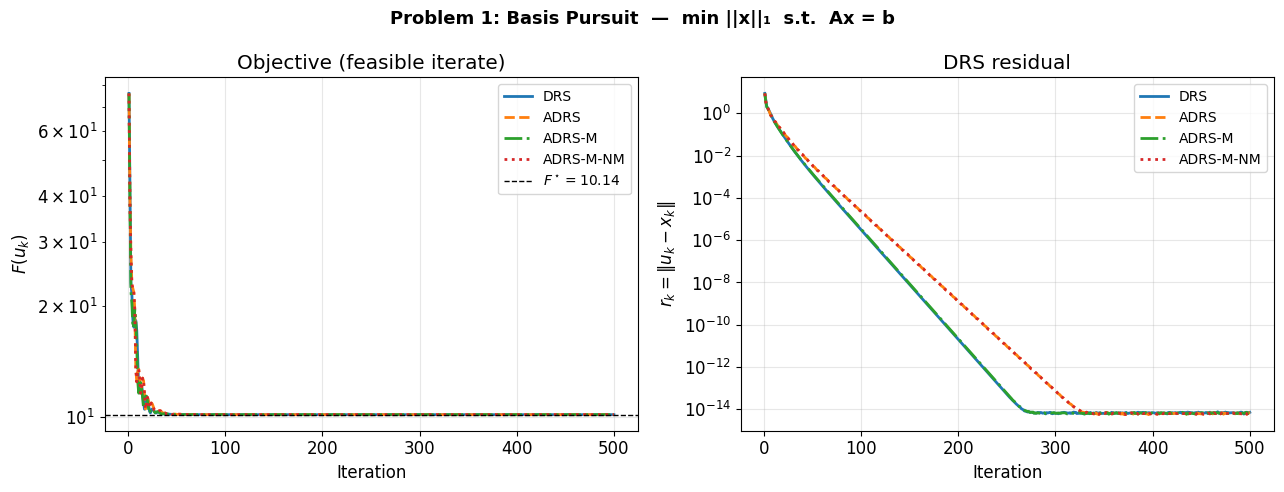


Algorithm       gap<1e+00  gap<1e-01  gap<1e-02  gap<1e-03  gap<1e-04
-----------------------------------------------------------------
DRS                   16        34        48        62        82
ADRS                  18        36        46        73        94
ADRS-M                16        22        48        61        81
ADRS-M-NM             18        36        46        73        94



In [5]:
res_bp = run_and_plot(
    algos_bp, z0_bp, NITERS_BP, F_STAR_BP,
    title="Problem 1: Basis Pursuit  —  min ||x||₁  s.t.  Ax = b",
    fname="p1_basis_pursuit.png"
)


---
## Problem 2: Nuclear Norm Distance + Nonnegativity Constraint

$$\min_{X \in \mathbb{R}^{m\times n}} \|X - M\|_* \quad\text{s.t.}\quad X \geq 0$$

Find the nonnegative matrix closest to $M$ in nuclear norm. Unlike Problem 1, the prox of $g_1$ requires an SVD at every iteration, introducing **spectrally nonlinear dynamics** that stress-test the monitor under non-polyhedral geometry.

**Splitting**: $g_1(X) = \|X - M\|_*$, $g_2 = \iota_{\{X \geq 0\}}$

- $\mathrm{prox}_{\alpha g_1}(Z) = M + U\,\mathrm{diag}((\sigma_i - \alpha)_+)\,V^\top$ — shifted SVT
- $\mathrm{prox}_{g_2}(Z) = \max(Z, 0)$ — elementwise ReLU

$u_k = \max(2x_k - z_k, 0) \geq 0$ always, so $F(u_k) = \|u_k - M\|_*$ is a valid feasible objective.


In [6]:
np.random.seed(2)
rows, cols, rank = 20, 20, 3

L  = np.random.randn(rows, rank)
R  = np.random.randn(cols, rank)
M  = L @ R.T      # low-rank matrix with mixed signs (nontrivial nonneg projection)

def prox1_nuc(Z, alpha):
    """prox_{alpha * ||. - M||_*}: shifted singular value soft thresholding."""
    D = Z - M
    U, s, Vt = np.linalg.svd(D, full_matrices=False)
    return M + (U * np.maximum(s - alpha, 0)) @ Vt

prox2_nuc = lambda Z, a: np.maximum(Z, 0)           # projection onto nonneg orthant
obj_nuc   = lambda U: float(np.sum(np.linalg.svd(U - M, compute_uv=False)))

# F* via long reference DRS run
z_ref = np.random.randn(rows, cols)
for _ in range(10000):
    x = prox1_nuc(z_ref, 1.0)
    u = prox2_nuc(2*x - z_ref, 1.0)
    z_ref = z_ref + u - x
F_STAR_NUC = obj_nuc(u)

z0_nuc    = np.random.randn(rows, cols)
ALPHA_NUC = 1.0
NITERS_NUC = 800

print(f"{rows}x{cols} matrix, rank={rank}")
print(f"F* (10k DRS) = {F_STAR_NUC:.6f}")
print(f"u nonneg: {np.all(u >= -1e-10)}")

algos_nuc = make_algorithms(prox1_nuc, prox2_nuc, obj_nuc, ALPHA_NUC)


20x20 matrix, rank=3
F* (10k DRS) = 53.942276
u nonneg: True


Running: Problem 2: Nuclear Norm  —  min ||X-M||_*  s.t.  X ≥ 0
  ADRS-M:    inertial 704/800 (88%)
  ADRS-M-NM: inertial 706/800 (88%)


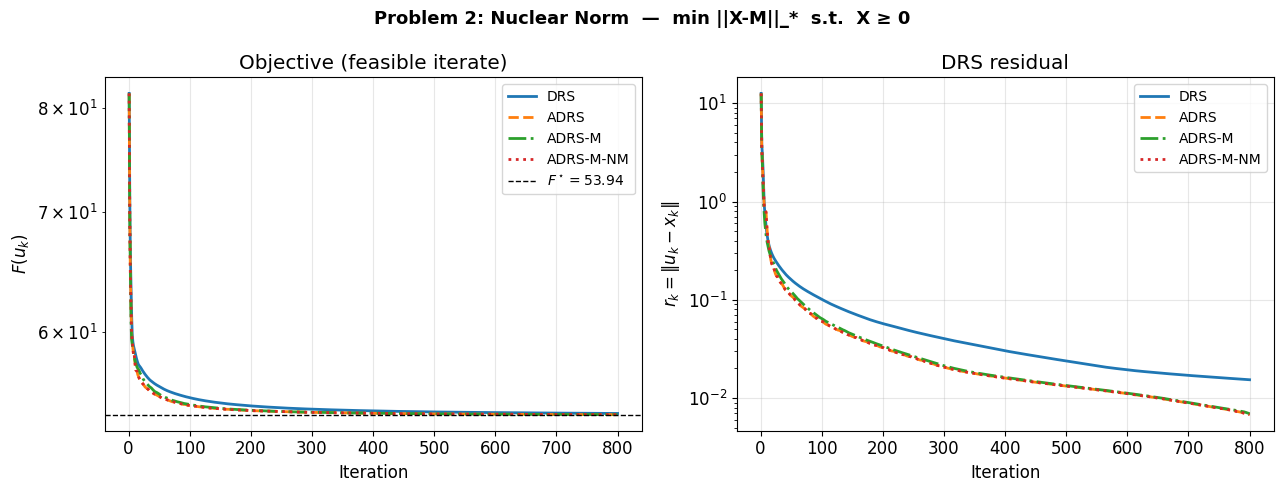


Algorithm       gap<1e+00  gap<1e-01  gap<1e-02  gap<1e-03  gap<1e-04
-----------------------------------------------------------------
DRS                  126       N/A       N/A       N/A       N/A
ADRS                  68       453       N/A       N/A       N/A
ADRS-M                75       459       N/A       N/A       N/A
ADRS-M-NM             68       453       N/A       N/A       N/A



In [7]:
res_nuc = run_and_plot(
    algos_nuc, z0_nuc, NITERS_NUC, F_STAR_NUC,
    title="Problem 2: Nuclear Norm  —  min ||X-M||_*  s.t.  X ≥ 0",
    fname="p2_nuclear_norm.png"
)


---
## Problem 3: Constrained Elastic Net

$$\min_{x \in \mathbb{R}^n} \|x\|_1 + \frac{\mu}{2}\|x\|^2 \quad\text{s.t.}\quad Ax = b$$

The elastic net penalty $\|x\|_1 + \frac{\mu}{2}\|x\|^2$ promotes sparse solutions while the $\ell_2$ term prevents degenerate degeneracy among correlated variables. The $\ell_1$ term makes the objective **nonsmooth**, so APG still cannot be applied.

**Splitting**: $g_1(x) = \|x\|_1 + \frac{\mu}{2}\|x\|^2$, $g_2 = \iota_{\{Ax=b\}}$

The prox of the elastic net has a closed form:
$$\mathrm{prox}_{\alpha g_1}(z)_i = \frac{\mathrm{sign}(z_i)}{1 + \alpha\mu}\max\!\left(|z_i| - \alpha,\, 0\right)$$


In [8]:
np.random.seed(0)
n, m, s = 200, 80, 10
mu = 0.1     # elastic net L2 weight

A2 = np.random.randn(m, n) / np.sqrt(m)
x_true2 = np.zeros(n)
x_true2[np.random.choice(n, s, replace=False)] = np.random.randn(s)
b2 = A2 @ x_true2
AAT_inv2 = np.linalg.inv(A2 @ A2.T)

def prox1_en(z, alpha):
    """prox_{alpha*(||.||_1 + mu/2*||.||^2)}: scaled soft thresholding."""
    return np.sign(z) * np.maximum(np.abs(z) - alpha, 0) / (1 + alpha * mu)

prox2_en = lambda z, a: z - A2.T @ (AAT_inv2 @ (A2 @ z - b2))
obj_en   = lambda u: np.sum(np.abs(u)) + (mu/2) * np.sum(u**2)

# F* via long DRS run
z_ref = np.random.randn(n)
for _ in range(5000):
    x = prox1_en(z_ref, 1.0)
    u = prox2_en(2*x - z_ref, 1.0)
    z_ref = z_ref + u - x
F_STAR_EN = obj_en(u)

z0_en    = np.random.randn(n)
ALPHA_EN = 1.0
NITERS_EN = 500

print(f"n={n}, m={m}, s={s}, mu={mu}")
print(f"F* (5k DRS) = {F_STAR_EN:.6f}")
print(f"Feasibility: ||Au - b|| = {np.linalg.norm(A2 @ u - b2):.2e}")

algos_en = make_algorithms(prox1_en, prox2_en, obj_en, ALPHA_EN)


n=200, m=80, s=10, mu=0.1
F* (5k DRS) = 10.801787
Feasibility: ||Au - b|| = 1.09e-14


Running: Problem 3: Constrained Elastic Net  —  min ||x||₁ + (μ/2)||x||²  s.t.  Ax = b
  ADRS-M:    inertial 311/500 (62%)
  ADRS-M-NM: inertial 310/500 (62%)


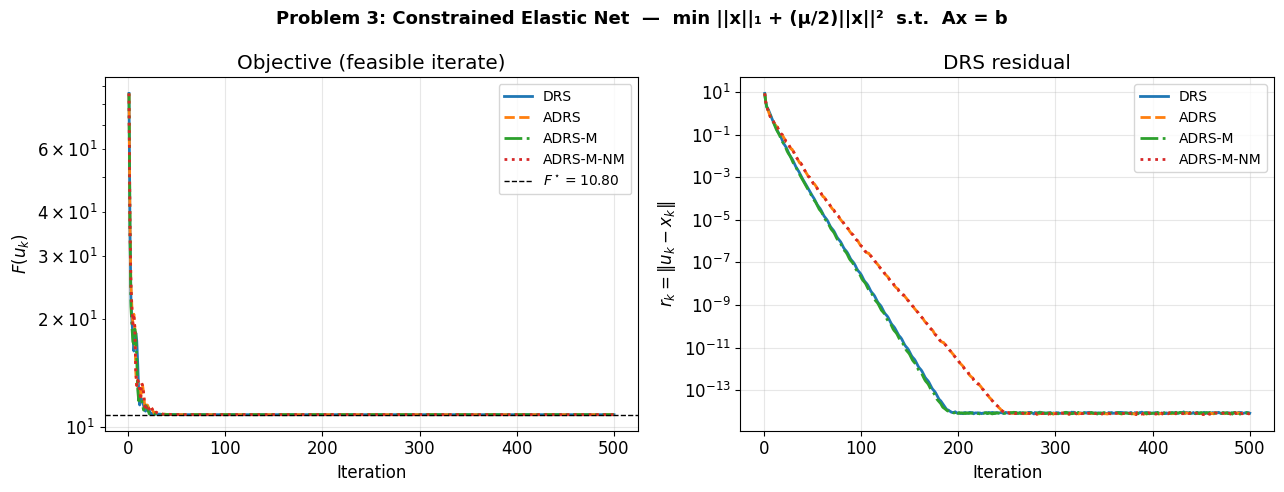


Algorithm       gap<1e+00  gap<1e-01  gap<1e-02  gap<1e-03  gap<1e-04
-----------------------------------------------------------------
DRS                   12        24        36        50        59
ADRS                  17        27        45        55        76
ADRS-M                15        22        34        48        60
ADRS-M-NM             17        27        45        55        76



In [9]:
res_en = run_and_plot(
    algos_en, z0_en, NITERS_EN, F_STAR_EN,
    title="Problem 3: Constrained Elastic Net  —  min ||x||₁ + (μ/2)||x||²  s.t.  Ax = b",
    fname="p3_elastic_net.png"
)


---
## Cross-problem comparison

Speedup of ADRS-M over DRS: how many fewer iterations to reach each tolerance?


In [10]:
tols = [1.0, 0.1, 0.01, 1e-3, 1e-4]
problem_results = [
    ("Basis Pursuit",    res_bp,  F_STAR_BP,  NITERS_BP),
    ("Nuclear Norm",     res_nuc, F_STAR_NUC, NITERS_NUC),
    ("Elastic Net",      res_en,  F_STAR_EN,  NITERS_EN),
]

print(f"{'Problem':<18}  {'Tol':<8}  {'DRS':>6}  {'ADRS':>6}  {'ADRS-M':>8}  {'ADRS-M-NM':>10}  {'Speedup (M/DRS)'}")
print("-" * 80)
for pname, res, fstar, ni in problem_results:
    for t in tols:
        row = []
        for alg in ['DRS','ADRS','ADRS-M','ADRS-M-NM']:
            gaps = res[alg][0] - fstar
            h = np.where(gaps < t)[0]
            row.append(h[0]+1 if len(h) else None)
        drs_itr, _, m_itr, _ = row
        speedup = f"{drs_itr/m_itr:.2f}x" if (drs_itr and m_itr) else "—"
        row_str = "  ".join(str(v) if v else "N/A" for v in row)
        print(f"{pname:<18}  {t:<8.0e}  {row_str}  {speedup:>10}")
    print()


Problem             Tol          DRS    ADRS    ADRS-M   ADRS-M-NM  Speedup (M/DRS)
--------------------------------------------------------------------------------
Basis Pursuit       1e+00     16  18  16  18       1.00x
Basis Pursuit       1e-01     34  36  22  36       1.55x
Basis Pursuit       1e-02     48  46  48  46       1.00x
Basis Pursuit       1e-03     62  73  61  73       1.02x
Basis Pursuit       1e-04     82  94  81  94       1.01x

Nuclear Norm        1e+00     126  68  75  68       1.68x
Nuclear Norm        1e-01     N/A  453  459  453           —
Nuclear Norm        1e-02     N/A  N/A  N/A  N/A           —
Nuclear Norm        1e-03     N/A  N/A  N/A  N/A           —
Nuclear Norm        1e-04     N/A  N/A  N/A  N/A           —

Elastic Net         1e+00     12  17  15  17       0.80x
Elastic Net         1e-01     24  27  22  27       1.09x
Elastic Net         1e-02     36  45  34  45       1.06x
Elastic Net         1e-03     50  55  48  55       1.04x
Elastic Net       

## Empirical convergence slopes

Fitting a line to the residual $\log r_k$ in the late-iteration regime gives the empirical rate. DRS should give a linear slope; acceleration should steepen it.


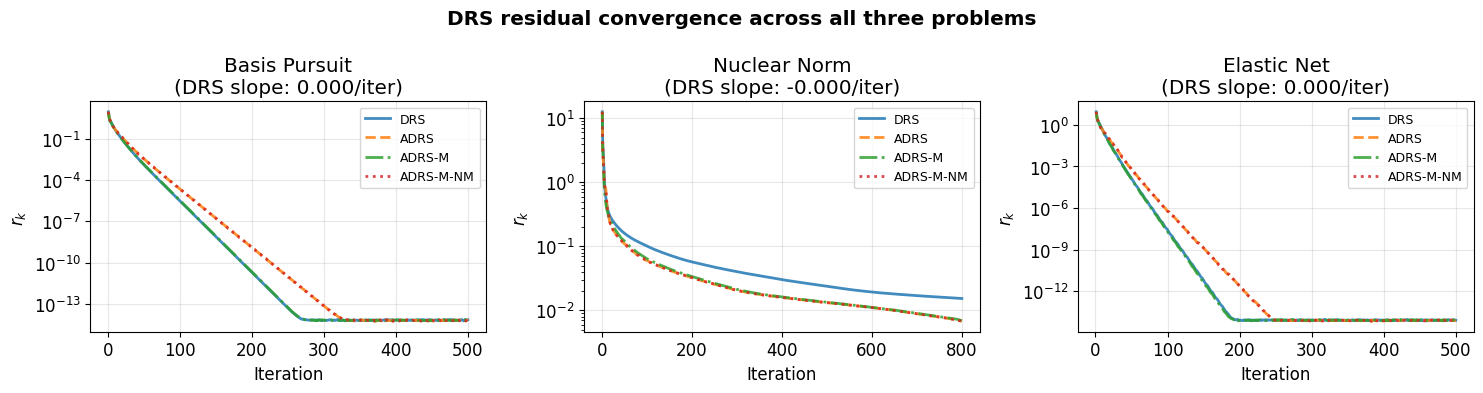

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("DRS residual convergence across all three problems", fontweight='bold')

configs = [
    ("Basis Pursuit",  res_bp,  NITERS_BP),
    ("Nuclear Norm",   res_nuc, NITERS_NUC),
    ("Elastic Net",    res_en,  NITERS_EN),
]

for ax, (title, res, ni) in zip(axes, configs):
    iters = np.arange(1, ni + 1)
    for name, (_, resids) in res.items():
        ax.semilogy(iters, resids, color=COLORS[name], linestyle=STYLES[name],
                    label=name, alpha=0.85)
    # Fit slope in last 20% of iterations for DRS
    drs_resids = res['DRS'][1]
    tail = drs_resids[int(0.8*ni):]
    if np.all(tail > 0):
        slope = np.polyfit(np.arange(len(tail)), np.log10(tail), 1)[0]
        ax.set_title(f"{title}\n(DRS slope: {slope:.3f}/iter)")
    else:
        ax.set_title(title)
    ax.set_xlabel("Iteration"); ax.set_ylabel("$r_k$")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("residual_slopes.png", dpi=130, bbox_inches='tight')
plt.show()
